## Notebook Purpose: To read evaluation tables containing results from varying detection thresholds and SNR thresholds applied on the bd2 detections post-overlap removal with threshold 12ms and using the TP-classification threshold of 12ms. Using these, we will plot different versions of precision-recall curves

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

## Function and Constant Definitions

In [3]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [4]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250130__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.012
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

In [5]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [6]:
batdetect2_eval_LF = pd.read_csv(BD2_DETS_SAVE_DIR / '20250129__bd2_LFeval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_HF = pd.read_csv(BD2_DETS_SAVE_DIR / '20250129__bd2_HFeval_results_per_thresh_and_file.csv', index_col=0)

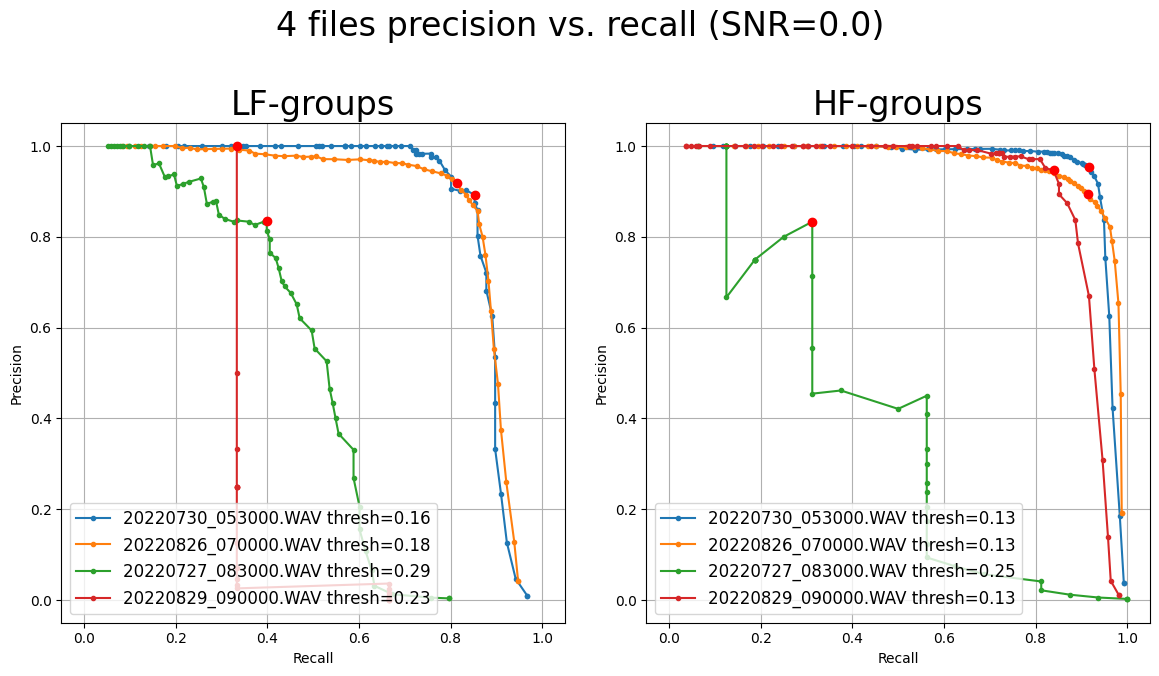

In [7]:
fig, (ax1, ax2), = plt.subplots(1, 2, figsize=(12,7))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'4 files precision vs. recall (SNR=0.0)')

ax1.set_title(f'LF-groups')
for file in batdetect2_eval_LF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_LF[batdetect2_eval_LF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax1.plot(file_recalls_SNR, file_precisions_SNR, marker='.',
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}')
    ax1.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', zorder=2)
ax1.grid(which='both')
ax1.set_xlim(-0.05,1.05)
ax1.set_ylim(-0.05,1.05)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.legend(loc='lower left', fontsize=12)

ax2.set_title(f'HF-groups')
for file in batdetect2_eval_HF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_HF[batdetect2_eval_HF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax2.plot(file_recalls_SNR, file_precisions_SNR, marker='.', 
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}')
    ax2.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', zorder=2)
ax2.grid(which='both')
ax2.set_xlim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left', fontsize=12)

fig.tight_layout()
plt.show()

In [8]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    precision = true_positives / denom_precision
    recall = true_positives / denom_recall
    
    return precision, recall

In [9]:
all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==4.0].groupby('detection_threshold')
all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
all_files_metrics_summed_by_det_thresh['precision'] = precision
all_files_metrics_summed_by_det_thresh['recall'] = recall

In [10]:
import matplotlib.cm as cm

# Get a colormap and normalize function for the colors
HF_colormap = cm.Reds
LF_colormap = cm.Blues
colormap = cm.Greys

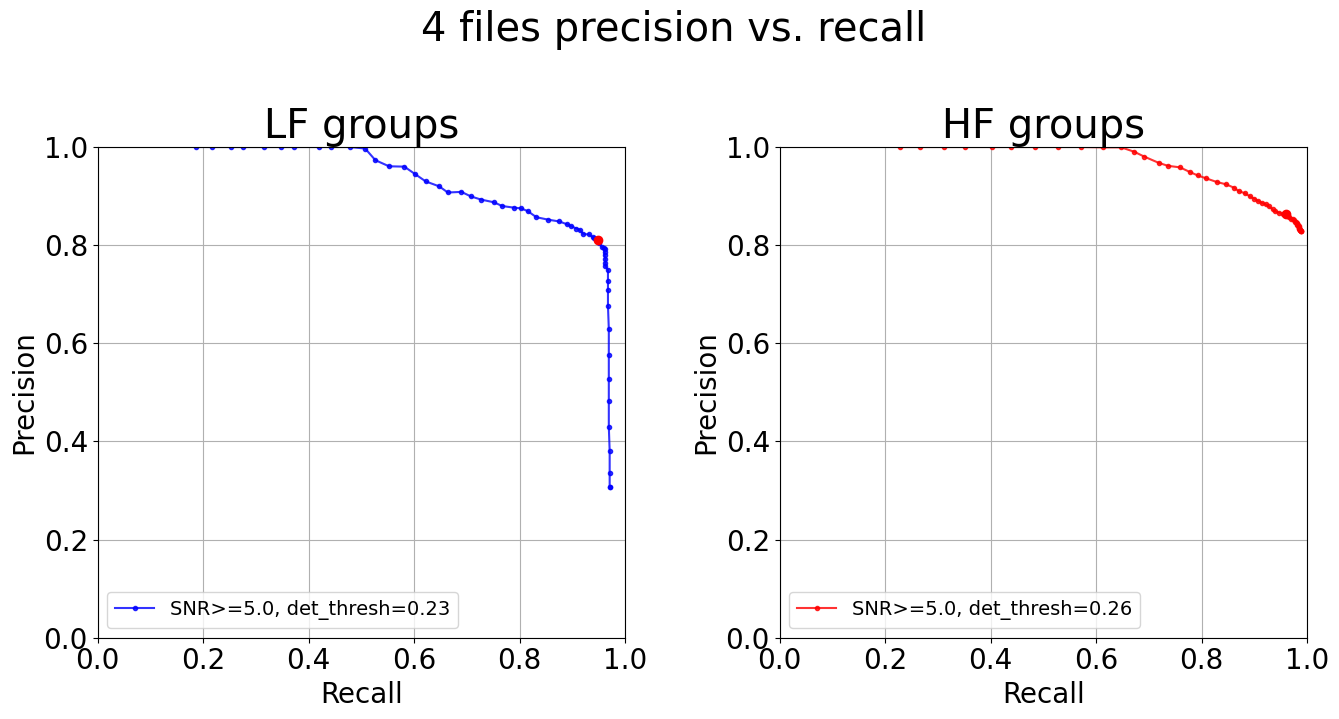

In [11]:
fig, ax_all, = plt.subplots(1, 2, figsize=(14,7.5))
ax_flatten = ax_all.flatten()
SNR_threshold = 5.0

plt.rcParams.update({'font.size':24})
fig.suptitle(f'4 files precision vs. recall')

ax = ax_flatten[0]
ax.set_title(f'LF groups')
lf_all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
lf_all_files_metrics_summed_by_det_thresh = lf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
LF_precision, LF_recall = get_precision_and_recall_from_metrics(lf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                        lf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                        lf_all_files_metrics_summed_by_det_thresh['false_negatives'])
thresholds = lf_all_files_metrics_summed_by_det_thresh.index
LF_quality_ind = (LF_precision*LF_recall).argmax()

ax.plot(LF_recall, LF_precision, marker='.', alpha=0.8, color='blue',
        label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[LF_quality_ind], 3)}')
ax.scatter(LF_recall.iloc[LF_quality_ind], LF_precision.iloc[LF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.0,1.0)
ax.set_ylim(0.0,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

ax = ax_flatten[1]
ax.set_title(f'HF groups')
hf_all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
hf_all_files_metrics_summed_by_det_thresh = hf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
HF_precision, HF_recall = get_precision_and_recall_from_metrics(hf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                        hf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                        hf_all_files_metrics_summed_by_det_thresh['false_negatives'])
thresholds = hf_all_files_metrics_summed_by_det_thresh.index
HF_quality_ind = (HF_precision*HF_recall).argmax()

ax.plot(HF_recall, HF_precision, marker='.', alpha=0.8, color='red',
        label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[HF_quality_ind], 3)}')
ax.scatter(HF_recall.iloc[HF_quality_ind], HF_precision.iloc[HF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.0,1.0)
ax.set_ylim(0.0,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
plt.show()

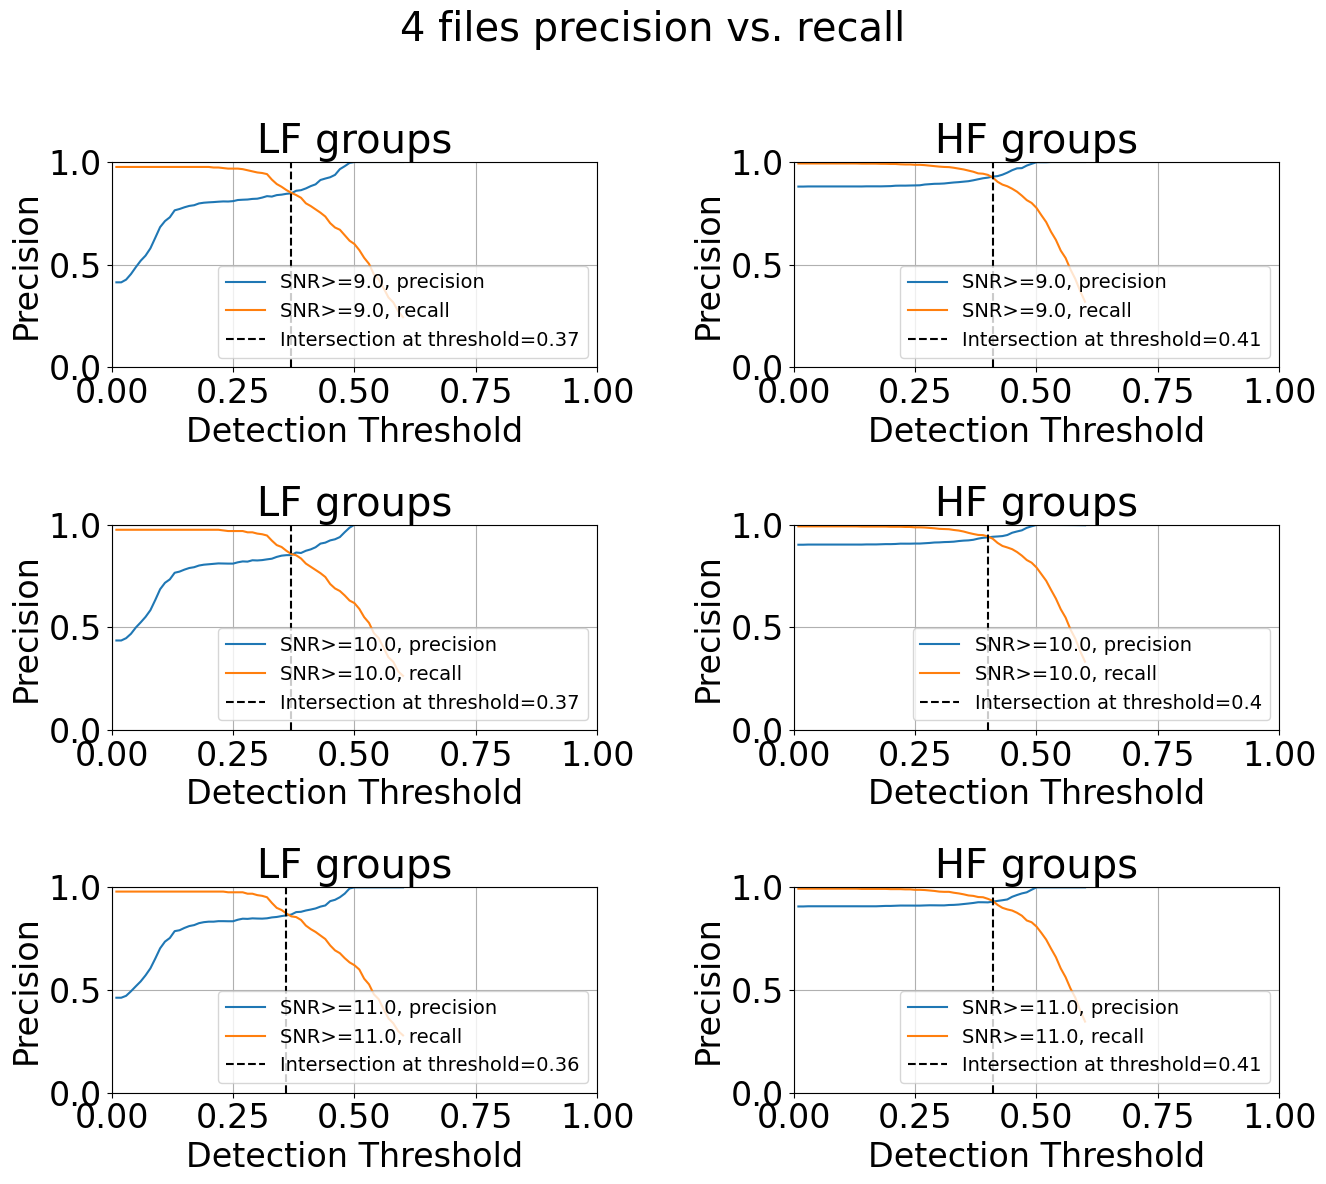

In [12]:
increment = 1.0
snr_thresholds = np.arange(9, 12, increment)
norm = plt.Normalize(vmin=min(snr_thresholds), vmax=max(snr_thresholds))

fig, ax_all, = plt.subplots(len(snr_thresholds), 2, figsize=(14,4*len(snr_thresholds)))
plt.rcParams.update({'font.size':24})
fig.suptitle(f'4 files precision vs. recall', y=1)
ax_flatten = ax_all.flatten()
for i, SNR_threshold in enumerate(snr_thresholds):

    ax = ax_flatten[2*i]
    ax.set_title(f'LF groups')
    lf_all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    lf_all_files_metrics_summed_by_det_thresh = lf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    LF_precision, LF_recall = get_precision_and_recall_from_metrics(lf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(LF_precision - LF_recall).argmin()]
    ax.plot(LF_precision, label=f'SNR>={round(SNR_threshold, 3)}, precision')
    ax.plot(LF_recall, label=f'SNR>={round(SNR_threshold, 3)}, recall')
    ax.axvline(x=optim_thresh, linestyle='dashed', color='k', label=f'Intersection at threshold={optim_thresh}')
    ax.grid(which='both')
    ax.set_xlim(0.0,1.0)
    ax.set_ylim(0.0,1.0)
    ax.set_xlabel('Detection Threshold')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower right', fontsize=14)

    ax = ax_flatten[(2*i)+1]
    ax.set_title(f'HF groups')
    hf_all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    hf_all_files_metrics_summed_by_det_thresh = hf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    HF_precision, HF_recall = get_precision_and_recall_from_metrics(hf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(HF_precision - HF_recall).argmin()]
    ax.plot(HF_precision, label=f'SNR>={round(SNR_threshold, 3)}, precision')
    ax.plot(HF_recall, label=f'SNR>={round(SNR_threshold, 3)}, recall')
    ax.axvline(x=optim_thresh, linestyle='dashed', color='k', label=f'Intersection at threshold={optim_thresh}')
    ax.grid(which='both')
    ax.set_xlim(0.0,1.0)
    ax.set_ylim(0.0,1.0)
    ax.set_xlabel('Detection Threshold')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower right', fontsize=14)

fig.tight_layout()
plt.show()

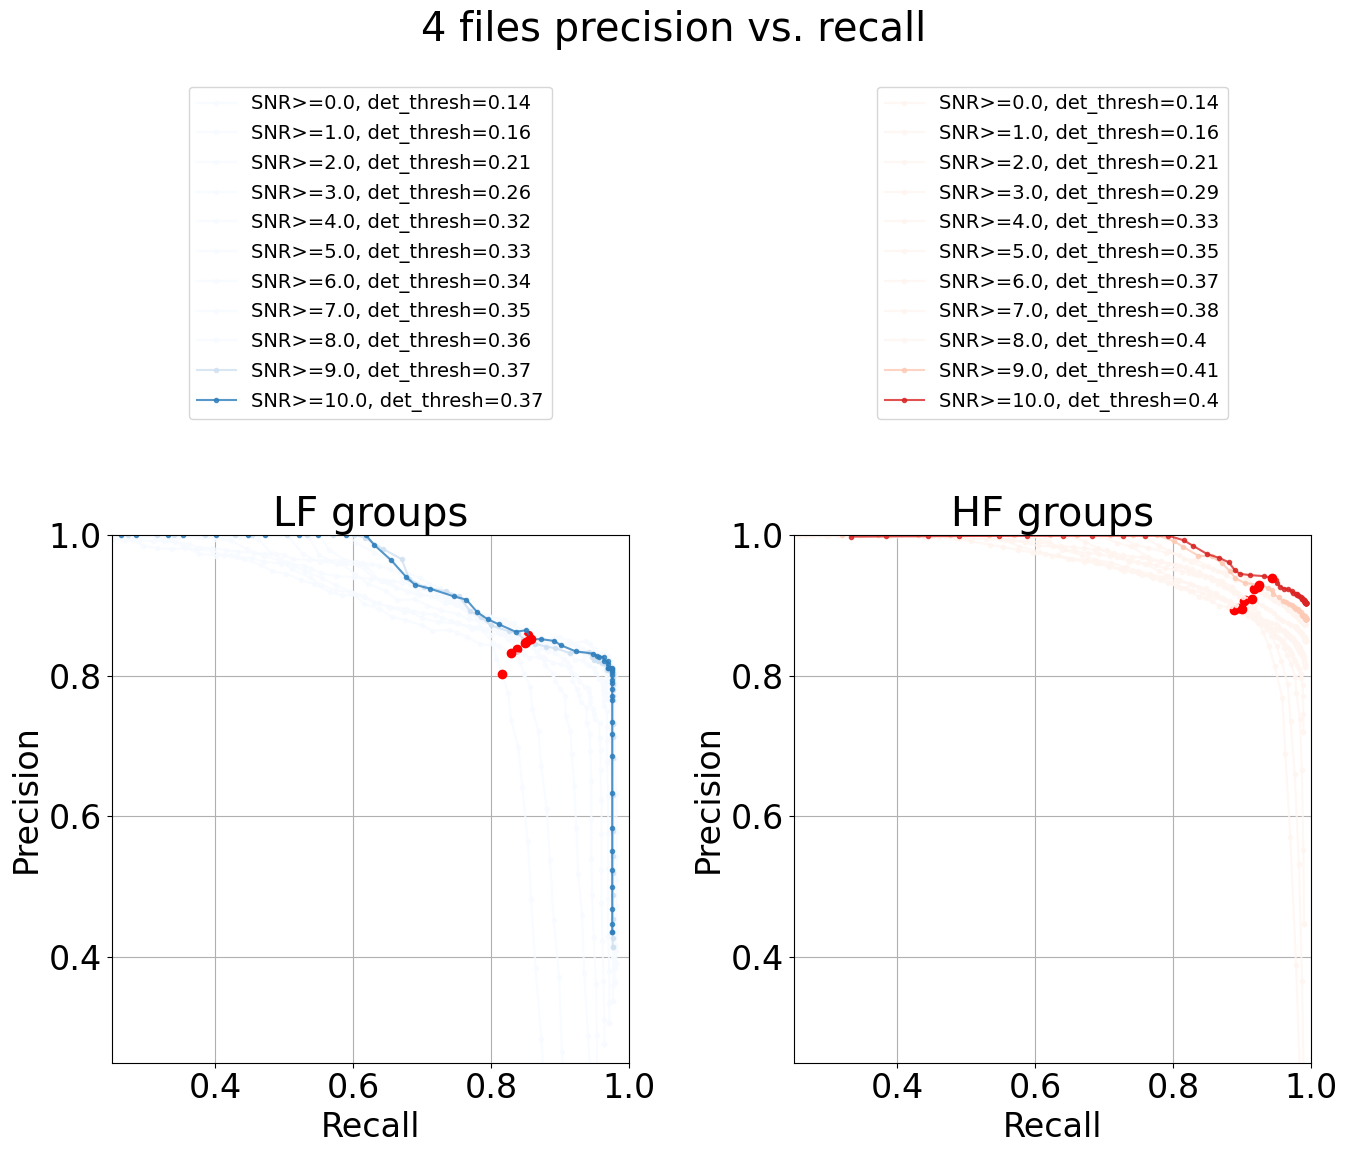

In [13]:
fig, ax_all, = plt.subplots(1, 2, figsize=(14,13))
ax_flatten = ax_all.flatten()

plt.rcParams.update({'font.size':24})
fig.suptitle(f'4 files precision vs. recall', y=0.90)
ax = ax_flatten[0]
ax.set_title(f'LF groups')
increment = 1.0
snr_thresholds = np.arange(0, 11, increment)
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    LF_precision, LF_recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    LF_quality_ind = np.abs(LF_precision - LF_recall).argmin()
    # Get color for current SNR threshold
    line_color = LF_colormap(0.2+norm(SNR_threshold))

    ax.plot(LF_recall, LF_precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[LF_quality_ind], 3)}')
    ax.scatter(LF_recall.iloc[LF_quality_ind], LF_precision.iloc[LF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.25,1.0)
ax.set_ylim(0.25,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='lower center', fontsize=14)

ax = ax_flatten[1]
ax.set_title(f'HF groups')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    HF_precision, HF_recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    HF_quality_ind = np.abs(HF_precision - HF_recall).argmin()
    # Get color for current SNR threshold
    line_color = HF_colormap(0.2+norm(SNR_threshold))

    ax.plot(HF_recall, HF_precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[HF_quality_ind], 3)}')
    ax.scatter(HF_recall.iloc[HF_quality_ind], HF_precision.iloc[HF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.25,1.0)
ax.set_ylim(0.25,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='lower center', fontsize=14)

fig.tight_layout()
plt.show()

In [14]:
increment = 1.0
snr_thresholds = np.arange(0, 20, increment)
norm = plt.Normalize(vmin=min(snr_thresholds), vmax=max(snr_thresholds))
LF_optim_threshes = []
HF_optim_threshes = []

for i, SNR_threshold in enumerate(snr_thresholds):
    lf_all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    lf_all_files_metrics_summed_by_det_thresh = lf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    LF_precision, LF_recall = get_precision_and_recall_from_metrics(lf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(LF_precision - LF_recall).argmin()]
    LF_optim_threshes += [optim_thresh]

    hf_all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    hf_all_files_metrics_summed_by_det_thresh = hf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    HF_precision, HF_recall = get_precision_and_recall_from_metrics(hf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(HF_precision - HF_recall).argmin()]
    HF_optim_threshes += [optim_thresh]

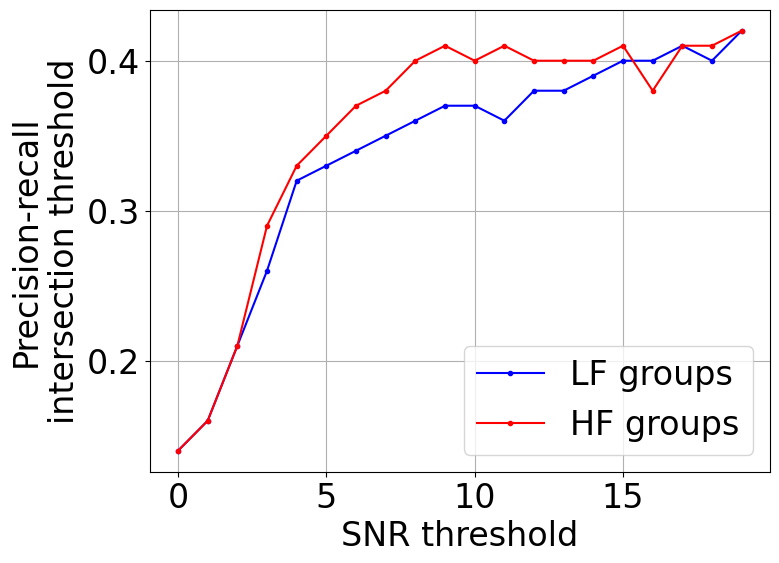

In [15]:
plt.figure(figsize=(8,6))
plt.plot(snr_thresholds, LF_optim_threshes, color='blue', marker='.', label='LF groups')
plt.plot(snr_thresholds, HF_optim_threshes, color='red', marker='.', label='HF groups')
plt.grid(which='both')
plt.xlabel('SNR threshold')
plt.legend()
plt.ylabel(f'Precision-recall\nintersection threshold')
plt.show()